# **Ground Detection – Klassifikation der Fahrbahnoberfläche**

Dieses Notebook klassifiziert die **Bodenbeschaffenheit der Fahrbahn** auf den Frames,
die zuvor im Notebook [`pre_processing.ipynb`](./pre_processing.ipynb) extrahiert wurden.

**Datengrundlage:** Die in `dataset/frames/<videoname>/original/` gespeicherten Einzelbilder
(1 Bild pro Sekunde) der frontal am Fahrradlenker montierten DJI-Kamera.

**Ziel:** Für den *Bikeability-Score* ist die Fahrbahnoberfläche $O_{surf}$ ein relevantes
Merkmal (vgl. [`README.md`](../README.md)). Glatter **Asphalt** ist fahrradfreundlich, während
**Kopfsteinpflaster**, **Schotter/Kies** oder ein **Erd-/Feldweg** den Fahrkomfort und damit
die Bikeability senken. Wir erkennen je Frame, ob der Boden z. B. asphaltiert ist, Kies bzw.
Schotter hat, aus Erde besteht, Kopfsteinpflaster ist usw.

**Methodik:** Da kein gelabelter Trainingsdatensatz für Oberflächentypen vorliegt, nutzen wir
analog zur YOLO-Pipeline ein **vortrainiertes Modell** im *Zero-Shot*-Verfahren:
[**CLIP**](https://github.com/openai/CLIP) (Contrastive Language–Image Pre-training) von OpenAI.
CLIP bettet Bilder und Textbeschreibungen in denselben Vektorraum ein. Wir vergleichen einen
**Bildausschnitt der Fahrbahn (ROI)** vor dem Rad mit textuellen Beschreibungen der
Oberflächentypen und wählen die Klasse mit der höchsten Ähnlichkeit – ganz ohne eigenes Training.

**Ablauf des Notebooks:**

1. **Setup & Modell laden** – CLIP-Modell (vortrainiert) und Textprompts vorbereiten.
2. **Konfiguration** – Pfade, Oberflächen-Klassen und die Fahrbahn-ROI definieren.
3. **ROI-Definition** – Den relevanten Bodenausschnitt vor dem Rad ausschneiden.
4. **Einzelbild-Test** – Klassifikation an einem Beispielframe visualisieren.
5. **Batch-Klassifikation** – Alle Frames verarbeiten, annotierte Bilder speichern.
6. **Auswertung** – Oberflächen-Verteilung je Video für die Bikeability-Analyse aggregieren.


## 1. Setup & Imports

`pip install torch transformers pillow opencv-python numpy matplotlib`

Beim ersten Aufruf lädt `transformers` die CLIP-Gewichte
(`openai/clip-vit-base-patch32`, ca. 600 MB) automatisch herunter und legt sie im
lokalen Cache ab. Ist eine CUDA-fähige GPU vorhanden, wird sie automatisch genutzt.


In [1]:
from __future__ import annotations

from collections import Counter
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image
from transformers import CLIPModel, CLIPProcessor

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch-Version: {torch.__version__}")
print(f"Rechengerät (Device): {DEVICE}")


/Users/hendrickfischer/Documents/Education/CAS_Master/Vorlesungen/Semester_2/Bildverarbeitung/RRCP_Project/computer_vision_bikeability_score/CRSvenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch-Version: 2.12.1
Rechengerät (Device): cpu


## 2. Konfiguration

Das Notebook liegt im Ordner `research/`, die Daten daher relativ unter `../dataset/`.
Wir verarbeiten die `original`-Frames und schreiben annotierte Bilder nach
`dataset/frames/<videoname>/ground/`.

**Oberflächen-Klassen:** Für jede Klasse definieren wir mehrere englische Textbeschreibungen
(*Prompts*), da CLIP auf englischsprachigen Bild-Text-Paaren trainiert wurde. Mehrere Prompts
pro Klasse erhöhen die Robustheit. Zusätzlich ordnen wir jeder Oberfläche einen
**Komfort-/Qualitätswert** $\in [0, 1]$ zu (1 = ideal fahrradfreundlich), der als
Feature $O_{surf}$ in den Bikeability-Score einfließen kann.


In [2]:
# Pfade (Notebook liegt in research/, daher eine Ebene höher)
FRAMES_DIR = Path("../dataset/frames")
SOURCE_SUBDIR = "original"   # Eingangs-Frames
OUTPUT_SUBDIR = "ground"     # Ziel für annotierte Bilder

# Modell
MODEL_NAME = "openai/clip-vit-base-patch32"
JPEG_QUALITY = 95
OVERWRITE = False

# Fahrbahn-ROI (relativ zur Bildgröße): unterer, mittiger Bildausschnitt direkt vor dem Rad.
# Werte als Anteil der Bildhöhe/-breite (0 = oben/links, 1 = unten/rechts).
ROI_TOP, ROI_BOTTOM = 0.62, 0.98
ROI_LEFT, ROI_RIGHT = 0.28, 0.72

# Oberflächen-Klassen: Name → (englische CLIP-Prompts, Komfort/Qualität 0..1)
SURFACE_CLASSES: dict[str, dict] = {
    "Asphalt/Beton": {
        "prompts": [
            "a photo of a smooth asphalt road surface",
            "a tarmac bike path",
            "black asphalt pavement",
            "a photo of a concrete road surface",
            "a smooth concrete pavement",
        ],
        "quality": 1.00,
    },
    "Pflaster/Kopfsteinpflaster": {
        "prompts": [
            "a photo of a road paved with rectangular paving stones",
            "interlocking concrete block paving",
            "a brick paved path",
            "a photo of a cobblestone street",
            "a rough cobbled road with round stones",
            "an old cobblestone pavement",
        ],
        "quality": 0.45,
    },
    "Schotter/Kies": {
        "prompts": [
            "a photo of a gravel road",
            "a path covered with loose gravel and small stones",
            "a crushed stone gravel track",
        ],
        "quality": 0.25,
    },
    "Erde/Feldweg": {
        "prompts": [
            "a photo of a dirt road made of bare soil",
            "an unpaved earth field path",
            "a muddy dirt track",
        ],
        "quality": 0.20,
    },
}

# Alle Videos mit vorhandenem original-Ordner finden
video_dirs = sorted(
    p.parent for p in FRAMES_DIR.glob(f"*/{SOURCE_SUBDIR}") if p.is_dir()
)

print(f"Gefundene Videos in '{FRAMES_DIR}/': {len(video_dirs)}")
for d in video_dirs:
    n = len(list((d / SOURCE_SUBDIR).glob("*.jpg")))
    print(f"  - {d.name}: {n} Frames")

if not video_dirs:
    print("\nKeine Frames gefunden. Bitte zuerst 'pre_processing.ipynb' ausführen.")


Gefundene Videos in '../dataset/frames/': 1
  - beispiel_dji_0390: 4 Frames


## 3. Modell laden & Textprompts vorbereiten

Wir laden das vortrainierte CLIP-Modell und berechnen **einmalig** die Text-Embeddings aller
Oberflächen-Prompts. Diese werden normalisiert, sodass die spätere Ähnlichkeit zum Bild über
das Skalarprodukt (Kosinus-Ähnlichkeit) berechnet werden kann.


In [3]:
model = CLIPModel.from_pretrained(MODEL_NAME).to(DEVICE).eval()
processor = CLIPProcessor.from_pretrained(MODEL_NAME)

# Flache Liste aller Prompts + Zuordnung Prompt-Index → Klassenname
prompts: list[str] = []
prompt_to_class: list[str] = []
for cls_name, cfg in SURFACE_CLASSES.items():
    for p in cfg["prompts"]:
        prompts.append(p)
        prompt_to_class.append(cls_name)

# Text-Embeddings einmalig berechnen und normalisieren
with torch.no_grad():
    text_inputs = processor(text=prompts, return_tensors="pt", padding=True).to(DEVICE)
    text_outputs = model.get_text_features(**text_inputs)
    # transformers >=5 liefert ein Output-Objekt (Embedding in .pooler_output),
    # <=4 liefert den Tensor direkt -> getattr deckt beide Versionen ab.
    text_features = getattr(text_outputs, "pooler_output", text_outputs)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

CLASS_NAMES = list(SURFACE_CLASSES)
print(f"Modell geladen: {MODEL_NAME}")
print(f"Klassen ({len(CLASS_NAMES)}): {CLASS_NAMES}")
print(f"Anzahl Textprompts: {len(prompts)}")


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 52456.81it/s]


Modell geladen: openai/clip-vit-base-patch32
Klassen (4): ['Asphalt/Beton', 'Pflaster/Kopfsteinpflaster', 'Schotter/Kies', 'Erde/Feldweg']
Anzahl Textprompts: 17


## 4. ROI-Definition & Klassifikationsfunktion

Aus der egozentrischen Perspektive befindet sich die relevante Fahrbahn im **unteren, mittigen
Bildbereich** direkt vor dem Rad. Der Himmel, Häuser oder parkende Autos im oberen Bereich
würden die Oberflächen-Klassifikation stören – daher schneiden wir gezielt eine *Region of
Interest* (ROI) aus.

Die Funktion `classify_surface` berechnet das (normalisierte) Bild-Embedding der ROI, vergleicht
es mit allen Text-Embeddings, aggregiert die Prompt-Ähnlichkeiten je Klasse (Maximum) und wandelt
die Werte per *Softmax* in Wahrscheinlichkeiten um.


In [4]:
def roi_bounds(height: int, width: int) -> tuple[int, int, int, int]:
    """Berechnet die Pixelgrenzen (y1, y2, x1, x2) der Fahrbahn-ROI."""
    y1 = int(ROI_TOP * height)
    y2 = int(ROI_BOTTOM * height)
    x1 = int(ROI_LEFT * width)
    x2 = int(ROI_RIGHT * width)
    return y1, y2, x1, x2


def crop_roi(image_bgr: np.ndarray) -> np.ndarray:
    """Schneidet die Fahrbahn-ROI aus einem BGR-Bild aus."""
    h, w = image_bgr.shape[:2]
    y1, y2, x1, x2 = roi_bounds(h, w)
    return image_bgr[y1:y2, x1:x2]


def classify_surface(roi_bgr: np.ndarray) -> dict[str, float]:
    """Klassifiziert die Oberfläche einer ROI per CLIP (Zero-Shot).

    Rückgabe: Dict {Klassenname: Wahrscheinlichkeit}, absteigend sortiert.
    """
    rgb = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(rgb)

    with torch.no_grad():
        img_inputs = processor(images=pil_img, return_tensors="pt").to(DEVICE)
        img_outputs = model.get_image_features(**img_inputs)
        # transformers >=5 liefert ein Output-Objekt (Embedding in .pooler_output),
        # <=4 liefert den Tensor direkt -> getattr deckt beide Versionen ab.
        img_features = getattr(img_outputs, "pooler_output", img_outputs)
        img_features = img_features / img_features.norm(dim=-1, keepdim=True)
        # Kosinus-Ähnlichkeit zu jedem Prompt
        sims = (img_features @ text_features.T).squeeze(0)  # [n_prompts]

    # Pro Klasse die stärkste Prompt-Ähnlichkeit verwenden
    class_sims = torch.tensor(
        [sims[[i for i, c in enumerate(prompt_to_class) if c == cls]].max()
         for cls in CLASS_NAMES]
    )
    # Softmax (Temperatur 100 = CLIP-Logit-Skala) → Wahrscheinlichkeiten
    probs = torch.softmax(class_sims * 100.0, dim=0)

    result = {cls: float(p) for cls, p in zip(CLASS_NAMES, probs)}
    return dict(sorted(result.items(), key=lambda kv: kv[1], reverse=True))


print("ROI- und Klassifikationsfunktionen definiert.")


ROI- und Klassifikationsfunktionen definiert.


## 5. Einzelbild-Test

Wir testen die Klassifikation an einem Beispielframe: Links das Originalbild mit eingezeichneter
ROI, rechts der ausgeschnittene Fahrbahnausschnitt samt erkannter Oberfläche und den
Wahrscheinlichkeiten aller Klassen.


Beispielframe: ../dataset/frames/beispiel_dji_0390/original/frame_00227.jpg
Erkannte Oberfläche: Asphalt/Beton (76.3%)
  Asphalt/Beton      76.3%
  Pflaster/Kopfsteinpflaster 17.9%
  Schotter/Kies       5.3%
  Erde/Feldweg        0.4%


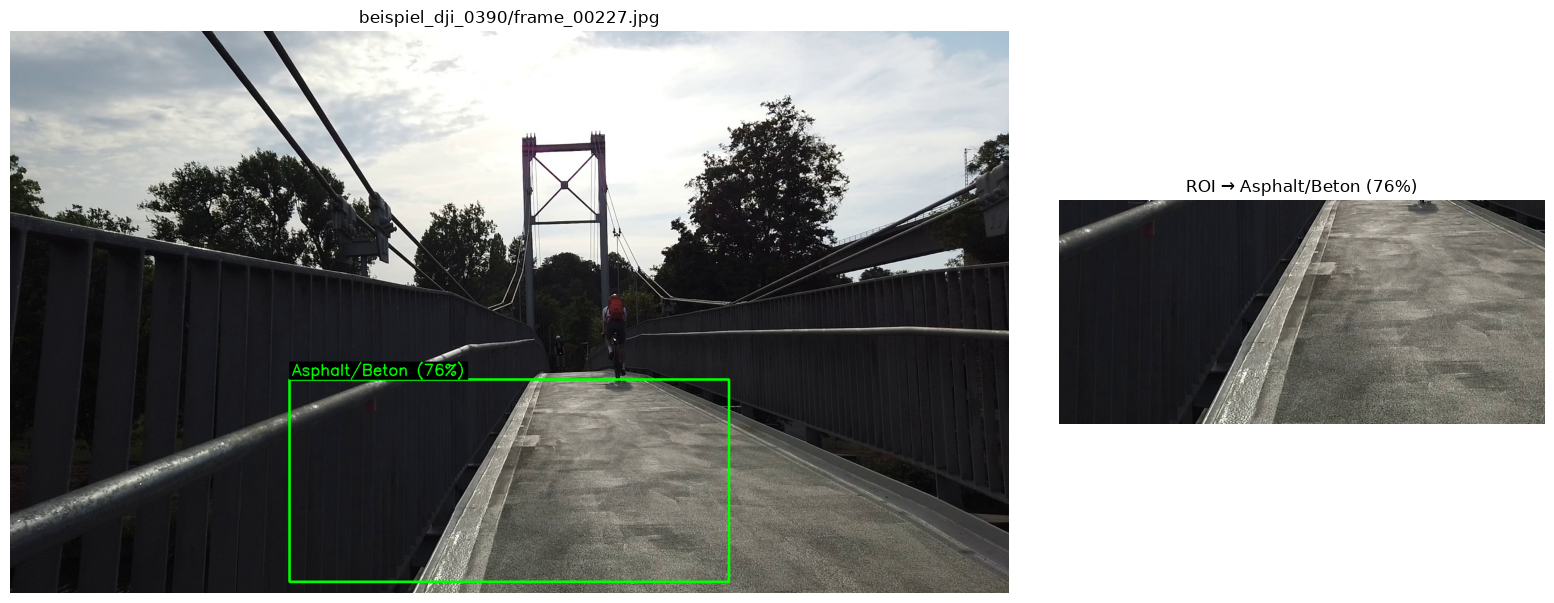

In [5]:
def annotate_frame(image_bgr: np.ndarray, label: str, prob: float) -> np.ndarray:
    """Zeichnet ROI-Rechteck und Label (Klasse + Wahrscheinlichkeit) auf das Bild."""
    out = image_bgr.copy()
    h, w = out.shape[:2]
    y1, y2, x1, x2 = roi_bounds(h, w)

    cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 3)
    text = f"{label} ({prob * 100:.0f}%)"
    font, scale, thick = cv2.FONT_HERSHEY_SIMPLEX, 1.0, 2
    (tw, th), _ = cv2.getTextSize(text, font, scale, thick)
    cv2.rectangle(out, (x1, y1 - th - 12), (x1 + tw + 10, y1), (0, 0, 0), -1)
    cv2.putText(out, text, (x1 + 5, y1 - 8), font, scale, (0, 255, 0), thick)
    return out


# Erstes verfügbares Frame als Beispiel wählen (mittleres Frame)
sample_frame = None
for d in video_dirs:
    frames = sorted((d / SOURCE_SUBDIR).glob("*.jpg"))
    if frames:
        sample_frame = frames[len(frames) // 2]
        break

if sample_frame is None:
    print("Kein Beispielframe gefunden.")
else:
    print(f"Beispielframe: {sample_frame}")
    image = cv2.imread(str(sample_frame))
    roi = crop_roi(image)

    probs = classify_surface(roi)
    top_label, top_prob = next(iter(probs.items()))
    print(f"Erkannte Oberfläche: {top_label} ({top_prob * 100:.1f}%)")
    for cls, p in probs.items():
        print(f"  {cls:<18}{p * 100:5.1f}%")

    annotated = annotate_frame(image, top_label, top_prob)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                             gridspec_kw={"width_ratios": [2.2, 1]})
    axes[0].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"{sample_frame.parent.parent.name}/{sample_frame.name}")
    axes[0].axis("off")

    axes[1].imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"ROI → {top_label} ({top_prob * 100:.0f}%)")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


## 6. Batch-Klassifikation über alle Frames

Die folgende Funktion klassifiziert die Oberfläche in allen `original`-Frames eines Videos,
speichert die annotierten Bilder nach `dataset/frames/<videoname>/ground/` und liefert pro Frame
die erkannte Klasse samt Wahrscheinlichkeit und Qualitätswert zurück.


In [6]:
def classify_video_frames(
    video_dir: Path,
    overwrite: bool = False,
) -> list[dict]:
    """Klassifiziert die Fahrbahnoberfläche aller original-Frames eines Videos.

    Annotierte Bilder werden nach <video_dir>/ground/ geschrieben.
    Rückgabe: Liste von Dicts mit Frame-Name, Klasse, Wahrscheinlichkeit und Qualität.
    """
    src_dir = video_dir / SOURCE_SUBDIR
    out_dir = video_dir / OUTPUT_SUBDIR
    out_dir.mkdir(parents=True, exist_ok=True)

    frame_paths = sorted(src_dir.glob("*.jpg"))
    records: list[dict] = []

    print(f"▶ {video_dir.name}: {len(frame_paths)} Frames")

    for frame_path in frame_paths:
        out_path = out_dir / frame_path.name
        image = cv2.imread(str(frame_path))
        if image is None:
            continue

        probs = classify_surface(crop_roi(image))
        top_label, top_prob = next(iter(probs.items()))

        if overwrite or not out_path.exists():
            annotated = annotate_frame(image, top_label, top_prob)
            cv2.imwrite(str(out_path), annotated,
                        [cv2.IMWRITE_JPEG_QUALITY, JPEG_QUALITY])

        records.append({
            "video": video_dir.name,
            "frame": frame_path.name,
            "surface": top_label,
            "confidence": round(top_prob, 4),
            "quality": SURFACE_CLASSES[top_label]["quality"],
        })

    print(f"  ✅ annotierte Bilder gespeichert in '{out_dir}'")
    return records


all_records: list[dict] = []
for video_dir in video_dirs:
    all_records.extend(classify_video_frames(video_dir, overwrite=OVERWRITE))

print(f"\nFertig. Insgesamt {len(all_records)} Frames klassifiziert.")


▶ beispiel_dji_0390: 4 Frames
  ✅ annotierte Bilder gespeichert in '../dataset/frames/beispiel_dji_0390/ground'

Fertig. Insgesamt 4 Frames klassifiziert.


## 7. Auswertung für die Bikeability-Analyse

Wir aggregieren die Oberflächen-Klassifikationen je Video: die Häufigkeit jeder Oberflächen-Klasse
sowie den **durchschnittlichen Oberflächen-Qualitätswert** $\bar{O}_{surf} \in [0, 1]$. Ein hoher
Wert (viel Asphalt/Beton) wirkt sich positiv auf den Bikeability-Score aus, ein niedriger Wert
(Kopfsteinpflaster, Schotter, Erde) negativ.


In [7]:
# Aggregation je Video: Häufigkeit pro Klasse + mittlerer Qualitätswert
summary: dict[str, dict] = {}
for rec in all_records:
    v = rec["video"]
    agg = summary.setdefault(
        v, {"frames": 0, "quality_sum": 0.0, **{c: 0 for c in CLASS_NAMES}}
    )
    agg["frames"] += 1
    agg["quality_sum"] += rec["quality"]
    agg[rec["surface"]] += 1

# Ausgabe als Tabelle
header = f"{'Video':<24}{'Frames':>7}"
for cls in CLASS_NAMES:
    header += f"{cls[:12]:>13}"
header += f"{'Ø Qualität':>12}"
print(header)

for v, agg in summary.items():
    row = f"{v:<24}{agg['frames']:>7}"
    for cls in CLASS_NAMES:
        row += f"{agg[cls]:>13}"
    mean_quality = agg["quality_sum"] / agg["frames"] if agg["frames"] else 0
    row += f"{mean_quality:>12.2f}"
    print(row)


Video                    Frames Asphalt/Beto Pflaster/Kop Schotter/Kie Erde/Feldweg  Ø Qualität
beispiel_dji_0390             4            4            0            0            0        1.00


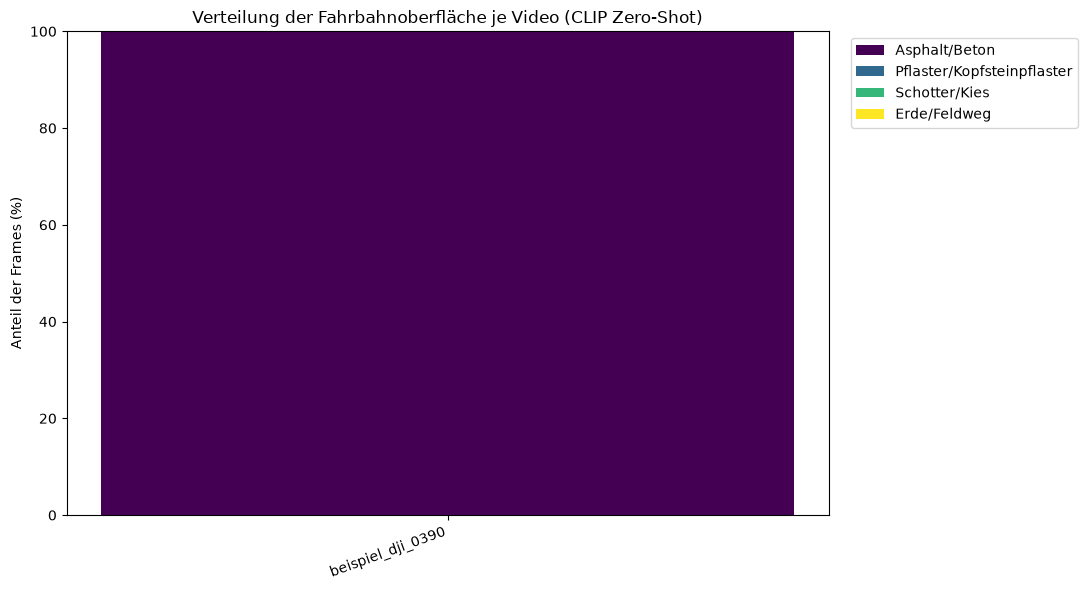

In [8]:
# Gestapeltes Balkendiagramm: Anteil der Oberflächen-Klassen je Video
if summary:
    videos = list(summary)
    x = np.arange(len(videos))
    cmap = plt.get_cmap("viridis", len(CLASS_NAMES))

    plt.figure(figsize=(11, 6))
    bottom = np.zeros(len(videos))
    for i, cls in enumerate(CLASS_NAMES):
        # Anteil (in %) der Klasse je Video
        shares = [summary[v][cls] / summary[v]["frames"] * 100 for v in videos]
        plt.bar(x, shares, bottom=bottom, label=cls, color=cmap(i))
        bottom += np.array(shares)

    plt.xticks(x, videos, rotation=20, ha="right")
    plt.ylabel("Anteil der Frames (%)")
    plt.title("Verteilung der Fahrbahnoberfläche je Video (CLIP Zero-Shot)")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("Keine Auswertungsdaten vorhanden.")
